--- Loading Data: data/Electric_Vehicle_Population_Data.csv ---
Target Distribution:
is_eligible
0    0.718911
1    0.281089
Name: proportion, dtype: float64

--- Training Logistic Regression (Tuning Regularization) ---


/Users/krishna/dev/pyenv/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/krishna/dev/pyenv/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(



--- Model Performance ---
Accuracy: 0.9995

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38986
           1       1.00      1.00      1.00     15237

    accuracy                           1.00     54223
   macro avg       1.00      1.00      1.00     54223
weighted avg       1.00      1.00      1.00     54223



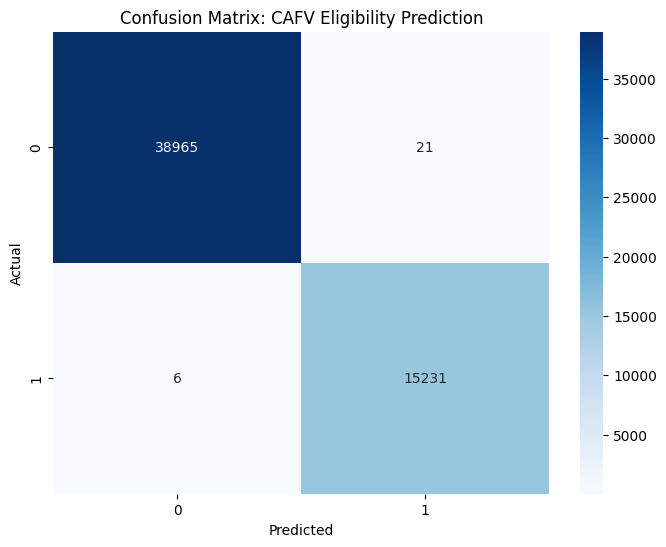


--- Top 5 Features Increasing Eligibility Likelihood ---
           Feature  Coefficient
1   Electric Range    55.642202
10  Make_CHEVROLET     9.192658
11   Make_CHRYSLER     7.541242
14     Make_FISKER     6.428202
9    Make_CADILLAC     5.382275


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def run_logistic_regression_workshop(csv_path):
    # 1. Load Data
    print(f"--- Loading Data: {csv_path} ---")
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print("Error: CSV not found. Please download from Data.gov.")
        return

    # 2. Define Binary Target
    # We want to predict if a vehicle is "Clean Alternative Fuel Vehicle Eligible"
    target_col = 'Clean Alternative Fuel Vehicle (CAFV) Eligibility'
    
    # Create binary target: 1 if Eligible, 0 otherwise
    df['is_eligible'] = (df[target_col] == 'Clean Alternative Fuel Vehicle Eligible').astype(int)
    
    features = ['Model Year', 'Make', 'Electric Vehicle Type', 'Electric Range']
    
    X = df[features]
    y = df['is_eligible']

    print(f"Target Distribution:\n{y.value_counts(normalize=True)}")

    # 3. Preprocessing
    # Logistic Regression is highly sensitive to feature scaling and cannot handle NaNs
    numeric_features = ['Model Year', 'Electric Range']
    categorical_features = ['Make', 'Electric Vehicle Type']

    # Create sub-pipelines to handle imputation and scaling/encoding in one go
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')), # Fill NaNs with the median value
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')), # Fill NaNs with a constant string
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    # 4. Split and Transform
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    X_train = preprocessor.fit_transform(X_train_raw)
    X_test = preprocessor.transform(X_test_raw)

    # 5. Train Logistic Regression with Cross-Validation
    # LogisticRegressionCV finds the best 'C' (inverse regularization strength)
    print("\n--- Training Logistic Regression (Tuning Regularization) ---")
    model = LogisticRegressionCV(
        cv=5, 
        random_state=42, 
        max_iter=1000, 
        scoring='accuracy',
        class_weight='balanced' # Handles cases where one class is more frequent
    )
    
    model.fit(X_train, y_train)

    # 6. Evaluation
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] # Probabilities for the 'Eligible' class

    print("\n--- Model Performance ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # 7. Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix: CAFV Eligibility Prediction')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    # 8. Interpretability: Top Predictors
    # Accessing feature names requires going through the categorical pipeline steps
    cat_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
    all_feature_names = numeric_features + list(cat_names)
    
    # Coefficients in Logistic Regression represent the 'Log-Odds'
    importance = pd.DataFrame({
        'Feature': all_feature_names,
        'Coefficient': model.coef_[0]
    }).sort_values(by='Coefficient', ascending=False)

    print("\n--- Top 5 Features Increasing Eligibility Likelihood ---")
    print(importance.head(5))

if __name__ == "__main__":
    # Ensure you are using the correct local path to your dataset
    FILE_PATH = 'data/Electric_Vehicle_Population_Data.csv'
    run_logistic_regression_workshop(FILE_PATH)